In [1]:
# Aggiungi src/ al path per importare config
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

In [21]:
# Import delle librerie necessarie
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from datasets import load_dataset
from qdrant_client import QdrantClient

# Import del file delle configurazione
from src.config import (
    RAW_DATA_DIR,
    DATASET_NAME,
    DATASET_CONFIG,
    DATASET_SPLIT,
    QDRANT_HOST,
    QDRANT_PORT,
    QDRANT_COLLECTION,
    RAG_RESPONSES_PATH,
    TOP_K_ABLATION,
    ABLATION_TOP_K_PATH,
    FIGURES_DIR,
    GENERATOR_MODEL,
    EVALUATION_REPORT_PATH
)

# Import funzioni pipeline RAG
from src.rag_pipeline import index_corpus, retrieve, build_rag_chain

# Import funzioni evaluation
from src.evaluation import generate_responses, run_ragas_evaluation

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [3]:
# Caricamento delle variabili d'ambiente
load_dotenv()

True

## FASE 1: Esplorazione del dataset

In [4]:
# Caricamento e preprocessing del dataset
dataset = load_dataset(
    DATASET_NAME,
    DATASET_CONFIG
)

split = dataset[DATASET_SPLIT]
print(f"Numero di esempi: {len(split)}")
print(f"Colonne: {split.column_names}")

# Visualizzazione del primo esempio
for col in split.column_names:
    val = split[0][col]
    print(f"{col}: {val}\n")

Numero di esempi: 20
Colonne: ['question', 'ground_truth', 'answer', 'contexts']
question: What are the global implications of the USA Supreme Court ruling on abortion?

ground_truth: The global implications of the USA Supreme Court ruling on abortion are significant. The ruling has led to limited or no access to abortion for one in three women and girls of reproductive age in states where abortion access is restricted. These states also have weaker maternal health support, higher maternal death rates, and higher child poverty rates. Additionally, the ruling has had an impact beyond national borders due to the USA's geopolitical and cultural influence globally. Organizations and activists worldwide are concerned that the ruling may inspire anti-abortion legislative and policy attacks in other countries. The ruling has also hindered progressive law reform and the implementation of abortion guidelines in certain African countries. Furthermore, the ruling has created a chilling effect in 

In [5]:
df = split.to_pandas()

# Lunghezza delle domande (in caratteri)
df["question_len"] = df["question"].str.len()

# Numero di contesti per sample
df["n_contexts"] = df["contexts"].apply(len)

# Lunghezza media dei contesti
df["avg_context_len"] = df["contexts"].apply(lambda ctxs: sum(len(c) for c in ctxs) / len(ctxs))

print(df[["question_len", "n_contexts", "avg_context_len"]].describe().round(1))

       question_len  n_contexts  avg_context_len
count          20.0        20.0             20.0
mean          105.0         3.0            529.7
std            41.7         0.0            154.2
min            29.0         3.0            299.7
25%            81.0         3.0            427.9
50%           108.5         3.0            530.7
75%           126.2         3.0            623.0
max           225.0         3.0            832.7


In [6]:
# Le metriche ContextRecall e FactualCorrectness richiedono il ground truth. Se non è presente su tutti i sample, quelle metriche falliranno su alcune righe
has_ground_truth = df["ground_truth"].notna() & (df["ground_truth"].str.len() > 0) # il doppio controllo serve a coniderare le stringhe vuote ("") come un NaN
print(f"Sample con ground truth: {has_ground_truth.sum()}/{len(df)}")

Sample con ground truth: 20/20


In [7]:
# Salviamo il dataset
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
split.save_to_disk(str(RAW_DATA_DIR))

print(f"Dataset salvato in {RAW_DATA_DIR}")

Saving the dataset (0/1 shards):   0%|          | 0/20 [00:00<?, ? examples/s]

Dataset salvato in C:\Users\antonio\Desktop\AI\RAG\ragas-mvp\data\raw\amnesty_qa


## FASE 2: Indicizzazione in Qdrant

In [8]:
# Estraiamo tutto il corpus dal dataset
all_context = []
for sample in split:
    all_context.extend(sample["contexts"])

# Eseguiamo ingestion in Qdrant
index_corpus(all_context)

Collection 'amnesty_qa' già esistente (60 vettori). Skip.


In [9]:
# Controlliamo che l'ingestion è avvenuta correttamente
client = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)
info = client.get_collection(QDRANT_COLLECTION)

print(f"Vettori indicizzati: {info.points_count}")
print(f"Status: {info.status}")
print(f"Vettori config: {info.config.params.vectors}")

Vettori indicizzati: 60
Status: green
Vettori config: {'dense': VectorParams(size=384, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None)}


In [10]:
# RAG chain
chain = build_rag_chain() 
#result = chain("What is the impact of the US Supreme Court abortion ruling?")
#result

## FASE 3: Generazione risposte RAG

In [11]:
# Se i risultati RAG non sono presenti su disco, eseguo il RAG
if RAG_RESPONSES_PATH.exists():
    with open(RAG_RESPONSES_PATH, "r", encoding="utf-8") as f:
        responses = json.load(f)
        print(f"Risposte caricate dal disco ({len(responses)} sample)")
else:
    responses = generate_responses(split, chain)
    print(f"\nEsempio risposta:")
    print(f"Q: {responses[0]['user_input']}")
    print(f"A: {responses[0]['response']}")

Risposte caricate dal disco (20 sample)


## FASE 4: RAGAS Evaluation

In [12]:
rows = []
for k in TOP_K_ABLATION:
    print(f"\n{'='*40}")
    print(f"Ablation: top_k = {k}")
    print(f"{'='*40}")

    chain_k = build_rag_chain(k)
    responses_k = generate_responses(split, chain_k)
    df_k = run_ragas_evaluation(responses_k)

    agg = df_k[["context_precision", "context_recall", "faithfulness", "answer_relevancy"]].mean()
    row = {"k": k, **agg.to_dict()}
    rows.append(row)
    print(f"\nk={k} → precision={row['context_precision']:.3f}, recall={row['context_recall']:.3f}, faithfulness={row['faithfulness']:.3f}")

ablation_df = pd.DataFrame(rows)

# Stampiamo i risultati
print("\n--- Risultati Ablation ---")
print(ablation_df.to_string(index=False))

# Salviamo i risultati
ABLATION_TOP_K_PATH.parent.mkdir(parents=True, exist_ok=True)
ablation_df.to_csv(ABLATION_TOP_K_PATH, index=False)
print(f"\nAblation salvata in {ABLATION_TOP_K_PATH}")


Ablation: top_k = 3


Generate responses:   0%|                                                                                                                                                                       | 0/20 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No sentence-transformers model found with name naver/splade-cocondenser-ensembledistil. Creating a new one with mean pooling.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: naver/splade-cocondenser-ensembledistil
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
bert.embeddings.position_ids               | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.predictions.decoder.weight             | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        
cls.predictions.decoder.bias               | UNEXPECTED |        
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        
pooler.dense.bias                          | MISSING    |        
pooler.dense.weight                        | MISSING    |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa


Salvati 20 risultati in C:\Users\antonio\Desktop\AI\RAG\ragas-mvp\data\results\rag_responses.json


Evaluating:   0%|          | 0/120 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



--- Aggregate Scores ---
        context_precision  context_recall  faithfulness  answer_relevancy  factual_correctness(mode=f1)  semantic_similarity
mean                0.676             1.0         0.970             0.976                         0.539                0.970
median              0.753             1.0         1.000             0.985                         0.535                0.973
std                 0.272             0.0         0.057             0.025                         0.264                0.019

k=10 → precision=0.676, recall=1.000, faithfulness=0.970

--- Risultati Ablation ---
 k  context_precision  context_recall  faithfulness  answer_relevancy
 3           0.654167            0.75      0.935260          0.977104
 5           0.702708            0.90      0.957321          0.973287
10           0.676329            1.00      0.970296          0.975505

Ablation salvata in C:\Users\antonio\Desktop\AI\RAG\ragas-mvp\data\results\ablation_top_k.csv


# FASE 5: Analisi e Visualizzazioni

In [14]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Stile uniforme per tutti i plot
sns.set_theme(style="whitegrid", font_scale=1.1)

### Plot 1 — Radar chart (4 metriche core)

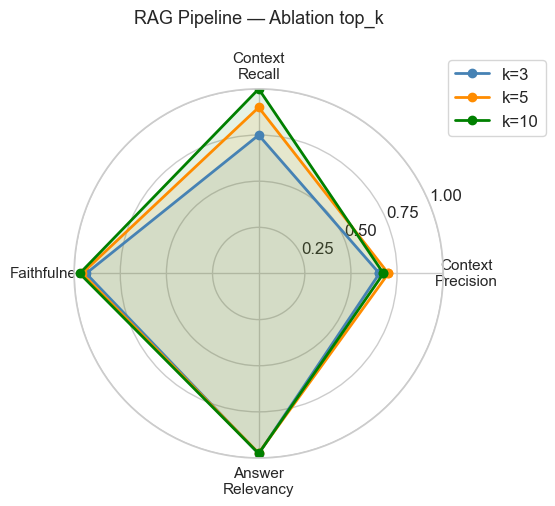

In [17]:
metrics_radar = ["context_precision", "context_recall", "faithfulness", "answer_relevancy"]
labels = ["Context\nPrecision", "Context\nRecall", "Faithfulness", "Answer\nRelevancy"]

angles = np.linspace(0, 2 * np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]

colors = ["steelblue", "darkorange", "green"]
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for _, row in ablation_df.iterrows():
  values = row[metrics_radar].tolist()
  values += values[:1]
  k = int(row["k"])
  color = colors[ablation_df.index[ablation_df["k"] == k].tolist()[0]]
  ax.plot(angles, values, "o-", linewidth=2, label=f"k={k}", color=color)
  ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_title("RAG Pipeline — Ablation top_k", pad=20, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot 2 — Line chart metriche vs k

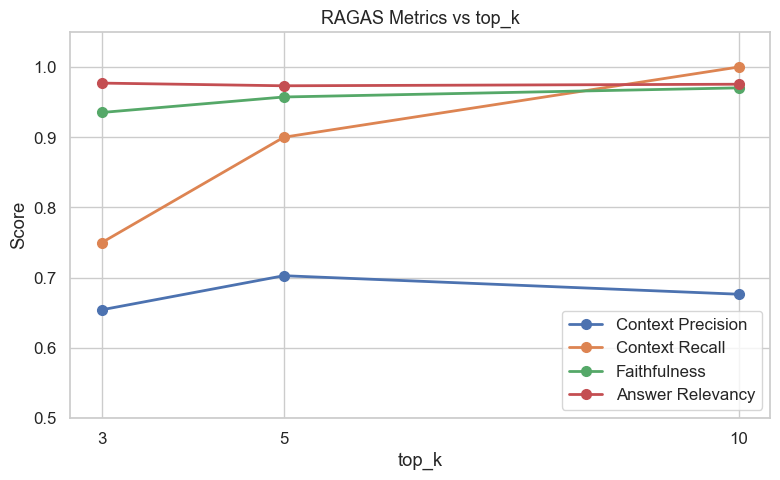

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

for col in ["context_precision", "context_recall", "faithfulness", "answer_relevancy"]:
  ax.plot(ablation_df["k"], ablation_df[col], "o-", label=col.replace("_", " ").title(), linewidth=2, markersize=7)

ax.set_xlabel("top_k")
ax.set_ylabel("Score")
ax.set_title("RAGAS Metrics vs top_k", fontsize=13)
ax.set_xticks([3, 5, 10])
ax.set_ylim(0.5, 1.05)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "linechart_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot 3 — Bar chart grouped

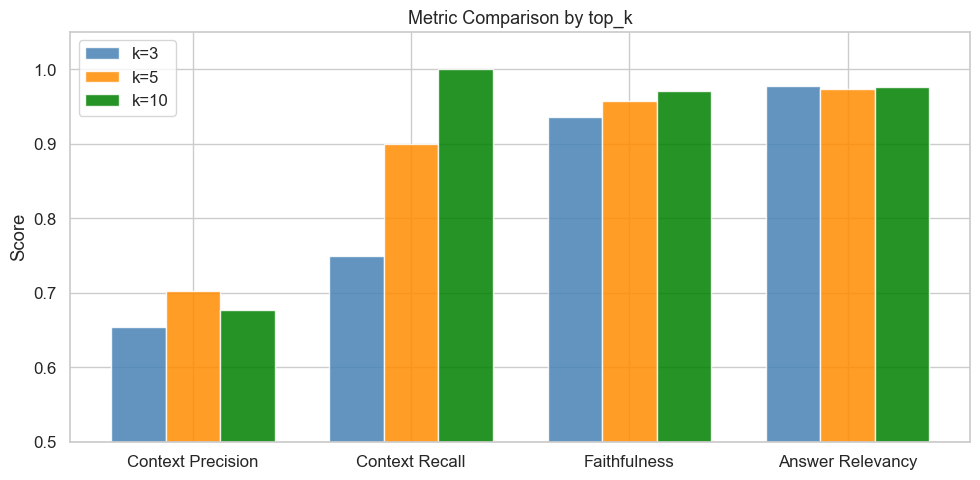

In [19]:
metrics = ["context_precision", "context_recall", "faithfulness", "answer_relevancy"]
x = np.arange(len(metrics))
width = 0.25
colors = ["steelblue", "darkorange", "green"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (_, row) in enumerate(ablation_df.iterrows()):
  ax.bar(x + i * width, row[metrics], width, label=f"k={int(row['k'])}", color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([m.replace("_", " ").title() for m in metrics])
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Score")
ax.set_title("Metric Comparison by top_k", fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "barchart_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## FASE 6: Report finale

In [25]:
# Prepariamo i dati da includere nel prompt
ablation_report = pd.read_csv(ABLATION_TOP_K_PATH)
ablation_table = ablation_report.to_string(index=False)

SYSTEM_PROMPT = """
You are a technical writer specializing in AI/ML evaluation reports.
Write a professional and concise evaluation report in Markdown format.
Base your analysis ONLY on the data provided. Be specific, cite the numbers.
"""

USER_PROMPT = """
Write a complete RAG evaluation report based on the following results.

## Project Context
- Dataset: vibrantlabsai/amnesty_qa (english_v2) — 20 samples on Amnesty International reports
- Embedding model: all-MiniLM-L6-v2 (dense, dim=384) + SPLADE (sparse) with RRF fusion
- Generator LLM: {generator_model}
- Vector DB: Qdrant with HybridSearch
- Evaluation framework: RAGAS (https://github.com/vibrantlabsai/ragas)
- Metrics: Context Precision, Context Recall, Faithfulness, Answer Relevancy

## Ablation Results (top_k = 3, 5, 10)
{ablation_table}

## Report Structure
Write the report with these sections:
1. Executive Summary (3-4 sentences, key findings)
2. Stack (bullet list)
3. Dataset (brief description)
4. Results (table + commentary on each metric trend)
5. Key Findings (what the metrics reveal, bottlenecks identified)
6. Optimal Configuration (which k and why)
7. Conclusions

Write in Italian language and translate setions name. Use Markdown formatting.
"""

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        SYSTEM_PROMPT
    ),
    (
        "human",
        USER_PROMPT
    )
])

llm = ChatOpenAI(model=GENERATOR_MODEL, temperature=0)
chain_report = prompt | llm | StrOutputParser()
report = chain_report.invoke({
    "generator_model": GENERATOR_MODEL,
    "ablation_table": ablation_table
})

# Salviamo il report
EVALUATION_REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(EVALUATION_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report)

# Stampiamo il report  
print(f"Report salvato in {EVALUATION_REPORT_PATH}")
print("\n" + "="*60 + "\n")
print(report)

Report salvato in C:\Users\antonio\Desktop\AI\RAG\ragas-mvp\reports\evaluation_report.md


# Rapporto di Valutazione RAG

## 1. Sintesi Esecutiva  
L’analisi delle prestazioni del sistema RAG sul dataset *vibrantlabsai/amnesty_qa* con 20 campioni ha evidenziato un miglioramento generale delle metriche al crescere del parametro *k* per la ricerca dei contesti. La *Context Recall* raggiunge il valore massimo di 1.00 a *k=10*, mentre la *Context Precision* mostra un picco a *k=5* con 0.703. La *Faithfulness* e la *Answer Relevancy* sono elevate in tutti i casi, con valori superiori a 0.93, indicando risposte affidabili e pertinenti.  

## 2. Stack Tecnologico  
- Dataset: vibrantlabsai/amnesty_qa (english_v2) — 20 campioni su report Amnesty International  
- Modello di embedding: all-MiniLM-L6-v2 (dense, dim=384) + SPLADE (sparse) con fusione RRF  
- Generatore LLM: gpt-4.1-mini  
- Database vettoriale: Qdrant con HybridSearch  
- Framework di valutazione: RAGAS (https://github.com/vibran